# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 03: Exploración de datos </center></h1>

**Fecha de Entrega:** 28 de octubre de 2025, a las 23:59.

**Fecha de publicación**: 14 de octubre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 03 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

---

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

En esta tarea vamos a analizar la distribución de vulneribilidad escolar para distintos establecimientos educacionales en Chile, desde enseñanza parvularia hasta enseñanza media. Específicamente, queremos entender cómo se comporta un índice de vulnerabilidad en relación a variables como ruralidad, tipo de dependencia y comuna del establecimiento.

---

## 2. Datos

En este estudio, trabajaremos con los resultados publicados anualmente sobre por la JUNAEB
sobre vulnerabilidad de establecimientos educacionales en todo el territorio nacional. Estos resultados están disponibles en la siguiente página web:

* Índices de Vulnerabilidad (JUNAEB): https://www.junaeb.cl/medicion-la-vulnerabilidad-ivm/

Adicionalmente, para visualizar las variables, utilizaremos los mapas vectoriales que disponibiliza la Biblioteca del Congreso Nacional (BCN):

* Mapoteca BCN: https://www.bcn.cl/siit/mapas_vectoriales/index_html

### 2.1 Descarga de datos y conceptos generales (1 punto)

Acceda a los links entregados y descargue el set de datos del **Índice de Vulnerabilidad Multidimensional de Establecimientos Educacionales** para el año 2025. Este debería ser un documento XLSX con múltiples pestañas, incluyendo entre estas un índice que describe las columnas presentes en la base de datos.
Descargue además los archivos correspondientes a la **División comunal: polígonos de las comunas de Chile**. Este se descarga en formato `.zip` y contiene archivos shapefile para visualizar las comunas del país.

Investigue sobre este índice y responda de manera concisa: 
* ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 
* ¿Cómo se obtiene el IVM de un establecimiento educacional?



#### **Respuestas 2.1**
* El rango de valores de cada elemento del IVM va desde 0 hasta 100, el valor 0 indicando que no hay vulnerabilidad y el valor 100 siendo la máxima vulnerabilidad posible (Según la info en https://www.junaeb.cl/medicion-la-vulnerabilidad-ivm/).
* Según el índice, el IVM de establecimiento se toma sacando el "IVM promedio del establecimiento".

## 3. Lectura y limpieza de datos (1 punto)

### 3.1 Datos de establecimientos (0.5 puntos)
El archivo descargado contiene información sobre establecimientos de cuatro tipos: Parvularia, Primer Ciclo Básica, Segundo Ciclo Básica y Media.
Cargue los datos de los establecimientos en cuatro DataFrames distintos.

Revise cada uno de sus sets de datos y haga un proceso de limpieza si lo considera necesario (manejo de valores nulos, duplicados, inválidos, transformación de tipos de datos, etc). De haberlos, identifique qué atributos son categóricos y transforme los tipos de columna de acuerdo a su decisión, mostrando todos los posibles valores de cada categoría.

Justifique **todas** sus decisiones, **incluso** si decide no realizar una limpieza o transformación.

Finalmente, responda:

* a. ¿Cuántos establecimientos tiene cada set de datos?
* b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?
* c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?


#### **Limpieza y transformación de datos**

In [1]:
# Imports.
import pandas as pd
import openpyxl # Usado para pd.read_excel()

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
### Abrir archivo, hacer DataFrames.
with open('data/IVM_Establecimientos_2025-2.xlsx', 'rb') as excel:
    todo_excel = pd.read_excel(excel, sheet_name=[1, 2, 3, 4])
df_parv = todo_excel[1]
df_1cic = todo_excel[2]
df_2cic = todo_excel[3]
df_medi = todo_excel[4]

### Limipieza (Parte 1)

## NaNs: Si hay valores NaN, eliminaré la fila.
df_parv.info()
#df_1cic.info()
#df_2cic.info()
#df_medi.info()
# No tienen NaN, no hay que sacar nada :D

## Duplicados: Eliminaré el duplicado, dejando el original.
df_parv = df_parv.drop_duplicates()
df_1cic = df_1cic.drop_duplicates()
df_2cic = df_2cic.drop_duplicates()
df_medi = df_medi.drop_duplicates()

## Inválidos: Si tiene valores IVM fuera de [0, 100], elimino la fila.
# Hago listas de las columnas a checkear por cada DataFrame.
cols_ivm_parv = ['IVM Establecimiento', 'IVM Salud', 'IVM CSE Familiar', 'IVM Estimulación y Apoyo', 'IVM Familia', 
                 'IVM CSE Comunal', 'IVM Derechos']
cols_ivm_1cic = ['IVM Establecimiento', 'IVM Salud', 'IVM Discapacidad', 'IVM Educación', 'IVM Habitabilidad',
                 'IVM Familiar', 'IVM Participación', 'IVM CSE Familia', 'IVM CSE Comunal']
cols_ivm_2cic = ['IVM Establecimiento'] # Tiene solo una columna para checkear, no necesito loop.
cols_ivm_medi = ['IVM Establecimiento'] # Tiene solo una columna para checkear, no necesito loop.
# Ahora checkeo y elimino lo que no esté entre 0 y 100.
for col in cols_ivm_parv:
    df_parv = (df_parv[(df_parv[col] >= 0) & (df_parv[col] <= 100)]).reset_index(drop=True)
for col in cols_ivm_1cic:
    df_1cic = (df_1cic[(df_1cic[col] >= 0) & (df_1cic[col] <= 100)]).reset_index(drop=True)
df_2cic = (df_2cic[(df_2cic['IVM Establecimiento'] >= 0) & (df_2cic['IVM Establecimiento'] <= 100)]).reset_index(drop=True)
df_medi = (df_medi[(df_medi['IVM Establecimiento'] >= 0) & (df_medi['IVM Establecimiento'] <= 100)]).reset_index(drop=True)

## Transformación: No la veo necesaria, dado a que según ".info()" todas las columnas son del tipo de valor que usaría.

## Otros: Podría eliminar columnas redundantes, por ejemplo "DS_COMUNA_ESTABLE", dado a que "ID_REGION_ESTABLE", 
## "ID_PROVINCIA_ESTABLE", y "ID_COMUNA_ESTABLE" proveen la misma info, pero no lo haré en caso de que la necesite en la tarea.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6163 entries, 0 to 6162
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_RBD                    6163 non-null   int64  
 1   DV_RBD                    6163 non-null   int64  
 2   DS_NOM_ESTABLE            6163 non-null   object 
 3   DS_TIPO_DEPENDENCIA       6163 non-null   object 
 4   DS_RURALIDAD              6163 non-null   object 
 5   ID_REGION_ESTABLE         6163 non-null   int64  
 6   ID_PROVINCIA_ESTABLE      6163 non-null   int64  
 7   ID_COMUNA_ESTABLE         6163 non-null   int64  
 8   DS_COMUNA_ESTABLE         6163 non-null   object 
 9   N EVALUADO                6163 non-null   int64  
 10  IVM Establecimiento       6163 non-null   float64
 11  IVM Bajo                  6163 non-null   int64  
 12  IVM Medio                 6163 non-null   int64  
 13  IVM Alto                  6163 non-null   int64  
 14  IVM Muy 

In [3]:
### Limpieza (Parte 2): Datos Categóricos.

## Datos categóricos: Mostaré todas las columnas categóricas, notando las decisiones que tomaré en cuanto a ellas.

# Datos categóricos no notables (Sin cambios y donde printear todos no importa mucho):
# "ID_RBD": Es el ID del establecimiento, un integer.
# "DV_RBD": Es el dígito verificador, un integer.
# "DS_NOM_ESTABLE": Solo tiene nombres de establecimiento, un string.
# "ID_REGION_ESTABLE": ID de región, un integer.
# "ID_PROVINCIA_ESTABLE": ID provincia, un integer.
# "ID_COMUNA_ESTABLE": ID comuna, un string.
# "DS_COMUNA_ESTABLE": Nombre de comuna, un string.

# Datos categóricos notables:
# "DS_TIPO_DEPENDENCIA": Sin cambios, no es un tipo de dato que pueda fácilmente transformar a otro.
print('Valores posibles de "DS_TIPO_DEPENDENCIA":', df_medi['DS_TIPO_DEPENDENCIA'].unique())
# "DS_RURALIDAD": Como solo puede ser "Urbano" o "Rural", puedo cambiarlo a bool, True si "Rural", False si "Urbano".
print('Valores posibles de "DS_RURALIDAD":', df_medi['DS_RURALIDAD'].unique())
df_parv['DS_RURALIDAD'] = (df_parv['DS_RURALIDAD'] == 'Rural') | (df_parv['DS_RURALIDAD'] == True)
df_1cic['DS_RURALIDAD'] = (df_1cic['DS_RURALIDAD'] == 'Rural') | (df_1cic['DS_RURALIDAD'] == True)
df_2cic['DS_RURALIDAD'] = (df_2cic['DS_RURALIDAD'] == 'Rural') | (df_2cic['DS_RURALIDAD'] == True)
df_medi['DS_RURALIDAD'] = (df_medi['DS_RURALIDAD'] == 'Rural') | (df_medi['DS_RURALIDAD'] == True)

Valores posibles de "DS_TIPO_DEPENDENCIA": ['Servicio Local de Educación(SLE)' 'Particular Subvencionado'
 'Administración Delegada (C. P. 3166)' 'Municipal DAEM'
 'Corporación Municipal']
Valores posibles de "DS_RURALIDAD": ['Urbano' 'Rural']


#### **Respuesta 3.1 a)**


In [4]:
sets_de_datos = [df_parv, df_1cic, df_2cic, df_medi]
# Setear nombre para el print.
df_parv.name = 'Parvularia'
df_1cic.name = '1° Ciclo Básico'
df_2cic.name = '2° Ciclo Básico'
df_medi.name = 'Media'
for df in sets_de_datos:
    print(f'El set de datos de {df.name} tiene {len(df)} establecimientos!')

El set de datos de Parvularia tiene 6163 establecimientos!
El set de datos de 1° Ciclo Básico tiene 7082 establecimientos!
El set de datos de 2° Ciclo Básico tiene 5662 establecimientos!
El set de datos de Media tiene 2618 establecimientos!


#### **Respuesta 3.1 b)**


In [5]:
memoria_parv = df_parv.memory_usage(deep=True).sum()
memoria_1cic = df_1cic.memory_usage(deep=True).sum()
memoria_2cic = df_2cic.memory_usage(deep=True).sum()
memoria_medi = df_medi.memory_usage(deep=True).sum()
memoria_total = memoria_parv + memoria_1cic + memoria_2cic + memoria_medi

print(f'En total, los 4 Dataframes usan {memoria_total} bytes de memoria!')

En total, los 4 Dataframes usan 8170816 bytes de memoria!


#### **Respuesta 3.1 c)**

In [6]:
sets_de_datos = [df_parv, df_1cic, df_2cic, df_medi]
for df in sets_de_datos:
    print(f"Para {df.name}, fueron evaluados {df['N EVALUADO'].sum()} estudiantes!")

Para Parvularia, fueron evaluados 255506 estudiantes!
Para 1° Ciclo Básico, fueron evaluados 882881 estudiantes!
Para 2° Ciclo Básico, fueron evaluados 484540 estudiantes!
Para Media, fueron evaluados 901899 estudiantes!


### 3.2 Datos geográficos (0.5 puntos)

Cargue en un GeoDataFrame de GeoPandas la información de los polígonos de cada comuna del país.

Como realizamos en la Tarea pasada, puede transformar el Coordinate Reference System (CRS) a EPSG 4326, para tener la información de los puntos de los polígonos con latitud y longitud.

#### **Respuesta 3.2**

<Axes: >

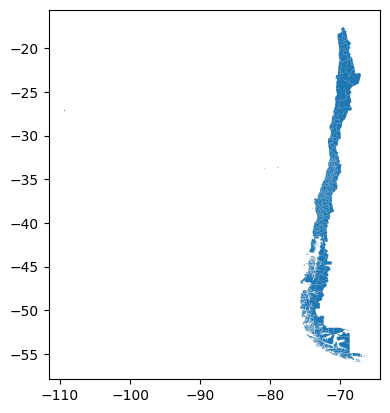

In [7]:
# Leo el archivo del mapa y lo convierto al CRS correcto.
mapa_no_crs = gpd.read_file('data/Comunas/comunas.shp')
mapa = mapa_no_crs.to_crs(4326)
mapa.plot()

## 4. Análisis descriptivo (1.5 puntos)

En esta sección haremos una exploración preliminar de los 4 sets de datos cargados. Para cada una de las siguientes preguntas, sustente su respuesta con al menos un gráfico y su análisis respectivo.

**Recomendación:** puede utilizar el método `subplots()` de `matplotlib.pyplot` para facilitar la visualización de múltiples gráficos a la vez.

### 4.1 Ruralidad (0.8 pts)
* a. ¿Cuál es la cantidad de establecimientos rurales vs urbanos según nivel de enseñanza?
* b. ¿Cómo se distribuye el IVM según nivel de enseñanza y ruralidad?


#### **Respuesta 4.1 a)**

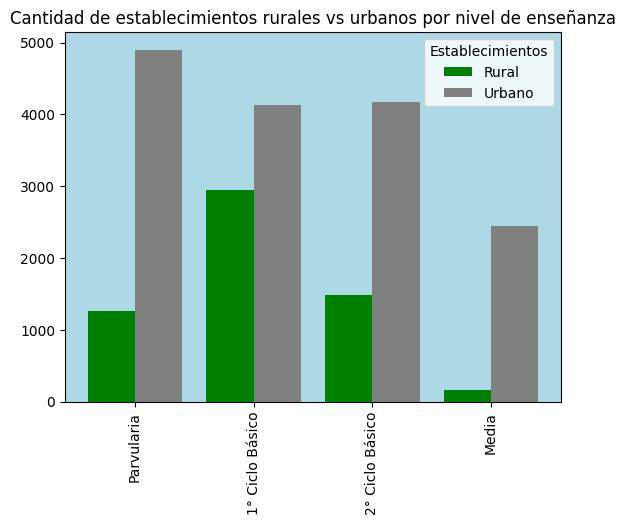

In [8]:
## a)
# Conseguir cantidad de rural y urbanos por nivel.
parv_r = (df_parv['DS_RURALIDAD'] == True).sum()
parv_u = (df_parv['DS_RURALIDAD'] == False).sum()

cic1_r = (df_1cic['DS_RURALIDAD'] == True).sum()
cic1_u = (df_1cic['DS_RURALIDAD'] == False).sum()

cic2_r = (df_2cic['DS_RURALIDAD'] == True).sum()
cic2_u = (df_2cic['DS_RURALIDAD'] == False).sum()

medi_r = (df_medi['DS_RURALIDAD'] == True).sum()
medi_u = (df_medi['DS_RURALIDAD'] == False).sum()

# Hago lista de categorias.
categorias = ['Parvularia', '1° Ciclo Básico', '2° Ciclo Básico', 'Media']
rural = [parv_r, cic1_r, cic2_r, medi_r]
urbano = [parv_u, cic1_u, cic2_u, medi_u]

# Subplot y parametros para el plot.
fig, ax = plt.subplots()
ancho = 0.4
index = np.arange(len(categorias))
ax.set_facecolor('lightblue')

# Barras de cada nivel.
ax.bar(index - ancho/2, rural, ancho, label='Rural', color='green')
ax.bar(index + ancho/2, urbano, ancho, label='Urbano', color='grey')

ax.set_xticks(index)
ax.set_xticklabels(categorias, rotation=90)
ax.set_title('Cantidad de establecimientos rurales vs urbanos por nivel de enseñanza')
ax.legend(title='Establecimientos')


**Respuesta y comentarios:** Se puede ver que hay muchos más establecimientos urbanos que rurales, y que en específico hay muchos establecimientos de "1° Ciclo Básico" rurales y muy pocos de "Media"

#### **Respuesta 4.1 b)**

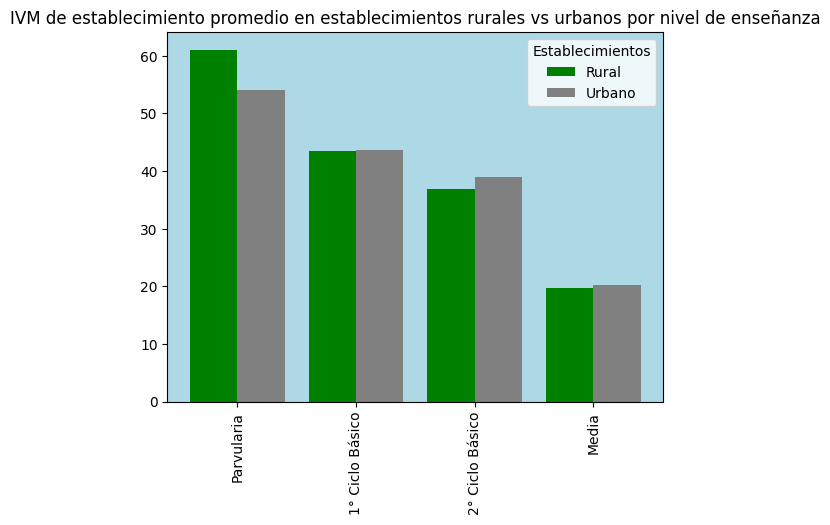

In [9]:
## b)
# Primero, sacaré el promedio de IVM (de establecimiento) por ruralidad en cada nivel.
pro_parv_rural = df_parv[df_parv['DS_RURALIDAD'] == True]['IVM Establecimiento'].mean()
pro_parv_urban = df_parv[df_parv['DS_RURALIDAD'] == False]['IVM Establecimiento'].mean()

pro_1cic_rural = df_1cic[df_1cic['DS_RURALIDAD'] == True]['IVM Establecimiento'].mean()
pro_1cic_urban = df_1cic[df_1cic['DS_RURALIDAD'] == False]['IVM Establecimiento'].mean()

pro_2cic_rural = df_2cic[df_2cic['DS_RURALIDAD'] == True]['IVM Establecimiento'].mean()
pro_2cic_urban = df_2cic[df_2cic['DS_RURALIDAD'] == False]['IVM Establecimiento'].mean()

pro_medi_rural = df_medi[df_medi['DS_RURALIDAD'] == True]['IVM Establecimiento'].mean()
pro_medi_urban = df_medi[df_medi['DS_RURALIDAD'] == False]['IVM Establecimiento'].mean()

categorias = ['Parvularia', '1° Ciclo Básico', '2° Ciclo Básico', 'Media']
promedio_rural = [pro_parv_rural, pro_1cic_rural, pro_2cic_rural, pro_medi_rural]
promedio_urbano = [pro_parv_urban, pro_1cic_urban, pro_2cic_urban, pro_medi_urban]

# Segundo, básicamente copio lo del 4.2 a) para hacer el gráfico de barras.
fig, ax = plt.subplots()
ancho = 0.4
index = np.arange(len(categorias))
ax.set_facecolor('lightblue')

ax.bar(index - ancho/2, promedio_rural, ancho, label='Rural', color='green')
ax.bar(index + ancho/2, promedio_urbano, ancho, label='Urbano', color='grey')

ax.set_xticks(index)
ax.set_xticklabels(categorias, rotation=90)
ax.set_title('IVM de establecimiento promedio en establecimientos rurales vs urbanos por nivel de enseñanza')
ax.legend(title='Establecimientos')

**Respuesta y comentarios:** Se puede ver que a excepción de "Parvularia", los establecimientos urbanos tienen mayor IVM de establecimiento promedio que los rurales.

### 4.2 Tipo de establecimiento (0.7 pts)

* ¿Cómo es la distribución del IVM promedio de los establecimientos según tipo de dependencia y nivel de enseñanza? 

#### **Respuesta 4.2**

{'Municipal DAEM', 'Administración Delegada (C. P. 3166)', 'Corporación Municipal', 'Servicio Local de Educación(SLE)', 'Particular Subvencionado'}


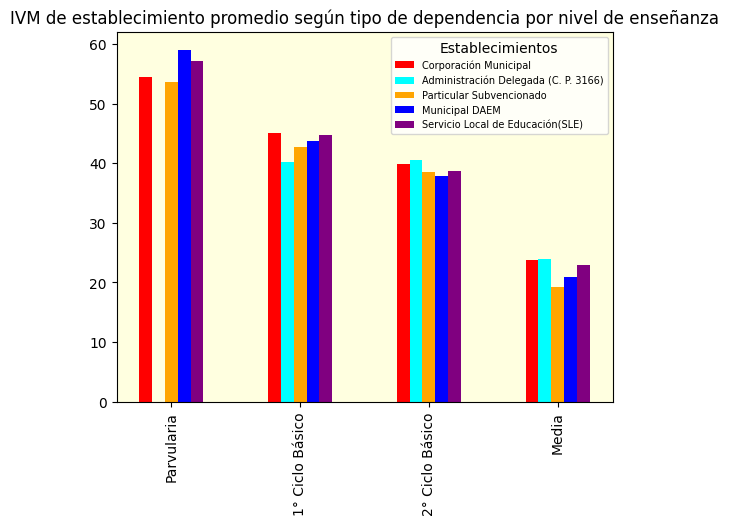

In [10]:
# Antes de todo, necesito saber los tipos de dependencia.
wagh = set()
wagh.update(df_parv['DS_TIPO_DEPENDENCIA'].unique())
wagh.update(df_1cic['DS_TIPO_DEPENDENCIA'].unique())
wagh.update(df_2cic['DS_TIPO_DEPENDENCIA'].unique())
wagh.update(df_medi['DS_TIPO_DEPENDENCIA'].unique())
print(wagh)
# Los tipos son:
# 'Corporación Municipal', 'Administración Delegada (C. P. 3166)', 'Particular Subvencionado', 'Municipal DAEM', 'Servicio Local de Educación(SLE)'
tipos_depen = ['Corporación Municipal', 'Administración Delegada (C. P. 3166)', 'Particular Subvencionado', 'Municipal DAEM', 'Servicio Local de Educación(SLE)']
nivel_edu = ['Parvularia', '1° Ciclo Básico', '2° Ciclo Básico', 'Media']

# Ahora prepararé las cosas para el plot porque haré un for loop para las barras.
fig, ax = plt.subplots()
ancho = 0.1
index = np.arange(len(categorias))
ax.set_facecolor('lightyellow')

colores = ['red', 'cyan', 'orange', 'blue', 'purple']

for i in range(len(tipos_depen)):
    var_parv = df_parv[df_parv['DS_TIPO_DEPENDENCIA'] == tipos_depen[i]]['IVM Establecimiento'].mean()
    var_1cic = df_1cic[df_1cic['DS_TIPO_DEPENDENCIA'] == tipos_depen[i]]['IVM Establecimiento'].mean()
    var_2cic = df_2cic[df_2cic['DS_TIPO_DEPENDENCIA'] == tipos_depen[i]]['IVM Establecimiento'].mean()
    var_medi = df_medi[df_medi['DS_TIPO_DEPENDENCIA'] == tipos_depen[i]]['IVM Establecimiento'].mean()
    promedio_actual = [var_parv, var_1cic, var_2cic, var_medi]
    ax.bar(index + (i - 5/2 + 0.5)*ancho, promedio_actual, width=ancho, label=tipos_depen[i], color=colores[i])

ax.set_xticks(index)
ax.set_xticklabels(categorias, rotation=90)
ax.set_title('IVM de establecimiento promedio según tipo de dependencia por nivel de enseñanza')
ax.legend(title='Establecimientos', fontsize=7)

**Respuesta y comentarios:** Honestamente no hay información importante que pueda sacar de este gráfico, pero algo curioso es que no hay "Administración Delegada" en nivel de educación "Parvularia".

### 4.3 Pregunta Bono: Dimensiones de vulnerabilidad (1 punto)

Para los niveles de enseñanza Parvularia y Básica Primer ciclo (1-4º), tenemos información sobre distintas dimensiones de que se utilizan para calcular el IVM, como condición socioeconómica familiar y comunal, salud, etc. 

* Para todo Chile, en promedio, ¿cuál es la dimensión con mayor puntaje de IVM para cada uno de estos dos niveles de enseñanza?

#### **Respuesta 4.3**

In [11]:
# Saco el promedio de cada IVM (excepto el de establecimiento) y muestro el mayor valor.
pro_ivm_parv = df_parv[['IVM Salud', 'IVM CSE Familiar', 'IVM Estimulación y Apoyo',
                        'IVM Familia', 'IVM CSE Comunal', 'IVM Derechos']].mean()
print(f'El mayor valor en promedio para "{df_parv.name}" es "{pro_ivm_parv.idxmax()}", siendo {pro_ivm_parv.max()}')

pro_ivm_1cic = df_1cic[['IVM Salud', 'IVM Discapacidad', 'IVM Educación', 'IVM Habitabilidad', 
                        'IVM Familiar', 'IVM Participación', 'IVM CSE Familia', 'IVM CSE Comunal']].mean()
print(f'El mayor valor en promedio para "{df_1cic.name}" es "{pro_ivm_1cic.idxmax()}", siendo {pro_ivm_1cic.max()}')

El mayor valor en promedio para "Parvularia" es "IVM Familia", siendo 70.66708502390739
El mayor valor en promedio para "1° Ciclo Básico" es "IVM CSE Familia", siendo 54.39076164533438


**Respuesta y comentarios:** Le hice print a la respuesta pero lo dejaré escrito aquí también.
* El mayor valor en promedio para "Parvularia" es "IVM Familia", siendo 70.66708502390739
* El mayor valor en promedio para "1° Ciclo Básico" es "IVM CSE Familia", siendo 54.39076164533438

## 5. Agrupación de bases de datos (2 puntos)

El objetivo de esta sección será agrupar los establecimientos según la comuna en la que se encuentran para obtener un resumen general sobre la vulnerabilidad escolar en cada una de ellas. Al finalizar esta sección, tendremos un nuevo DataFrame `agg_comunal` que contenga, al menos, la siguiente información:

* Comuna (nombre y ID)
* Región (ID)
* Cantidad de establecimientos rurales de la comuna
* Cantidad de establecimientos urbanos de la comuna
* Cantidad total de establecimientos de la comuna
* Porcentaje de establecimientos rurales
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna
* Objeto geometry de GeoPandas correspondiente al polígono de la comuna respectiva

Armaremos este DataFrame paso a paso.

### 5.1 Cálculo de IVM promedio por comuna (0.8 pts)

Primero, para cada uno sus 4 DataFrames, calcule el promedio de la columna `IVM Establecimiento` según comuna. Almacene este valor en una nueva columna llamada `IVM Promedio {NIVEL DE ENSEÑANZA}` (por ejemplo, para enseñanza parvularia, cree la columna `IVM Promedio Parvularia`).

Junte los 4 resultados que obtuvo en un solo DataFrame `ivm_comunal` que contenga:
* Comuna (nombre y ID)
* Región (ID)
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna

Ponga siempre atención al tamaño de sus DataFrames: como estamos agrupando comunalmente, estos siempre debiesen tener una cantidad de filas igual a las comunas de Chile.

#### **Respuesta 5.1*** (leer nota abajo)

**!!!!!** Hola! Resulta que al equivocarme al leer, sin querer hice el "agg_comunal" en vez del "ivm_comunal" aquí.

In [12]:
# Parte 1: Añadir columna de promedio por comuna.
mis_dataframes = [df_parv, df_1cic, df_2cic, df_medi]
for df in mis_dataframes:
    for comuna in df['ID_COMUNA_ESTABLE'].unique():
        df.loc[df['ID_COMUNA_ESTABLE'] == comuna, f'IVM Promedio {df.name}'] = df[df['ID_COMUNA_ESTABLE'] == comuna]['IVM Establecimiento'].mean()


In [13]:
# Parte 2: Armar DataFrame 2.
agg_comunal = pd.DataFrame(columns=['DS_COMUNA_ESTABLE', 'ID_COMUNA_ESTABLE', 'ID_REGION_ESTABLE', 'N_ESTABLECIMIENTOS_URBANOS',
                                   'N_ESTABLECIMIENTOS_RURALES', 'N_ESTABLECIMIENTOS', 'PORCENTAJE_RURALES','IVM Promedio Parvularia', 
                                    'IVM Promedio 1° Ciclo Básico', 'IVM Promedio 2° Ciclo Básico', 'IVM Promedio Media', 'GEOMETRY'])

# Ahora debo encontrar todas las comunas que hay, lo haré por ID.
wagh = set()
wagh.update(df_parv['ID_COMUNA_ESTABLE'].unique())
wagh.update(df_1cic['ID_COMUNA_ESTABLE'].unique())
wagh.update(df_2cic['ID_COMUNA_ESTABLE'].unique())
wagh.update(df_medi['ID_COMUNA_ESTABLE'].unique())

# 
mis_dataframes = [df_parv, df_1cic, df_2cic, df_medi]
id_est_vistos = set()
for id_comuna in wagh:
    est_urbanos = 0
    est_rurales = 0

    first = True
    for df in mis_dataframes:
        if first:
            df_temp = df[['DS_COMUNA_ESTABLE', 'ID_COMUNA_ESTABLE', 'ID_REGION_ESTABLE']].copy()
            df_temp['N_ESTABLECIMIENTOS_URBANOS'] = 0
            df_temp['N_ESTABLECIMIENTOS_RURALES'] = 0
            df_temp['N_ESTABLECIMIENTOS'] = 0
            df_temp['PORCENTAJE_RURALES'] = 0
            df_temp['GEOMETRY'] = 'placeholder wagh'
            df_temp = df_temp.drop_duplicates(subset='ID_COMUNA_ESTABLE', inplace=False, ignore_index=True)
            df_temp = df_temp[df_temp['ID_COMUNA_ESTABLE'] == id_comuna].reset_index(drop=True)
            first = False
        est_urbanos += ((df['DS_RURALIDAD'] == False) & (df['ID_COMUNA_ESTABLE'] == id_comuna) & (~df['ID_RBD'].isin(id_est_vistos)) ).sum()
        est_rurales += ((df['DS_RURALIDAD'] == True) & (df['ID_COMUNA_ESTABLE'] == id_comuna) & (~df['ID_RBD'].isin(id_est_vistos)) ).sum()
        id_est_vistos.update(df.loc[df['ID_COMUNA_ESTABLE'] == id_comuna, 'ID_RBD'])
        df_temp[f'IVM Promedio {df.name}'] = df[df['ID_COMUNA_ESTABLE'] == id_comuna]['IVM Establecimiento'].mean()
        
    df_temp['N_ESTABLECIMIENTOS_URBANOS'] = est_urbanos
    df_temp['N_ESTABLECIMIENTOS_RURALES'] = est_rurales
    df_temp['N_ESTABLECIMIENTOS'] = est_urbanos + est_rurales
    df_temp['PORCENTAJE_RURALES'] = round((est_rurales/(est_urbanos + est_rurales))*100, 2)

    agg_comunal = pd.concat([agg_comunal, df_temp], axis=0, ignore_index=True)



# oops, hice el agg_comunal, así que aquí está el ivm_comunal.
ivm_comunal = agg_comunal[['DS_COMUNA_ESTABLE', 'ID_COMUNA_ESTABLE', 'ID_REGION_ESTABLE', 'IVM Promedio Parvularia', 
                           'IVM Promedio 1° Ciclo Básico', 'IVM Promedio 2° Ciclo Básico', 'IVM Promedio Media']].copy()
ivm_comunal.head()
#agg_comunal.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1764\1286359635.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  agg_comunal = pd.concat([agg_comunal, df_temp], axis=0, ignore_index=True)


,DS_COMUNA_ESTABLE,ID_COMUNA_ESTABLE,ID_REGION_ESTABLE,IVM Promedio Parvularia,IVM Promedio 1° Ciclo Básico,IVM Promedio 2° Ciclo Básico,IVM Promedio Media
0,La Serena,4101,4,51.506968,41.929986,38.801087,19.179865
1,Coquimbo,4102,4,52.586458,43.070147,39.407055,19.783487
2,Andacollo,4103,4,54.889702,40.437711,38.345534,19.096251
3,La Higuera,4104,4,64.099665,42.271636,39.136469,25.054125
4,Paiguano,4105,4,60.593769,43.529075,37.617313,19.105727


### 5.2 Establecimientos por comuna y ruralidad (0.8 pts)

Ahora contaremos la cantidad de establecimientos por comuna según ruralidad. Como buscamos la cantidad total de establecimientos, consideramos establecimientos de todos los niveles educacionales vistos. Para esto, combine los 4 DataFrames que cargó y genere un nuevo DataFrame `estab_comunal` que contenga:

* Comuna (ID)
* Cantidad de establecimientos rurales
* Cantidad de establecimientos urbanos
* Cantidad total de establecimientos
* Porcentaje de establecimientos rurales (Establecimientos rurales / Total establecimientos * 100)

Tenga en cuenta de que pueden aparecer establecimientos duplicados al combinar estos 4 DataFrames (por ejemplo, establecimientos que imparten múltiples niveles de enseñanza, desde 1º básico hasta 4º medio). Preocúpese de manejar estos casos antes de agrupar sus datos según ruralidad.

#### **Respuesta 5.2*** (leer nota de 5.1)

In [14]:
# respuestas
estab_comunal = agg_comunal[['ID_COMUNA_ESTABLE', 'N_ESTABLECIMIENTOS_RURALES', 'N_ESTABLECIMIENTOS_URBANOS', 
                             'N_ESTABLECIMIENTOS', 'PORCENTAJE_RURALES']].copy()
estab_comunal.head()

,ID_COMUNA_ESTABLE,N_ESTABLECIMIENTOS_RURALES,N_ESTABLECIMIENTOS_URBANOS,N_ESTABLECIMIENTOS,PORCENTAJE_RURALES
0,4101,15,111,126,11.90
1,4102,11,105,116,9.48
2,4103,6,5,11,54.55
3,4104,6,1,7,85.71
4,4105,7,3,10,70.00


### 5.3 Unión de bases de datos y polígonos (0.4 pts)

Finalmente, vamos a generar el DataFrame `agg_comunal` con la información de los dos previos DataFrames creados.
Combine la información de las dos secciones anteriores para crear su base de datos unificada. Por último, agregue la columna `geometry` con la información geográfica de cada comuna.

#### **Respuesta 5.3**

In [15]:
# respuestas
gdf_comunas = gpd.read_file('data/Comunas/comunas.shp')
gdf_comunas.head()

# 'ID_COMUNA_ESTABLE' == 'cod_comuna' ?? Tal vez.
gdf_simple = gdf_comunas[['cod_comuna', 'geometry']].copy()

agg_comunal = agg_comunal.merge(gdf_simple[['cod_comuna', 'geometry']], how='left', left_on='ID_COMUNA_ESTABLE', right_on='cod_comuna')
agg_comunal = agg_comunal.drop(columns=['cod_comuna', 'GEOMETRY'])
agg_comunal.head(3)

## 6. Análisis de vulnerabilidad por comuna (1.5 puntos)

### 6.1 Mapa de calor (0.8 pts)

Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales. Realice esto para cada etapa de enseñanza (Parvularia, Básica 1, Básica 2 y Media). Analice y comente sus resultados:
* ¿Cómo se diferencia la vulnerabilidad en distintos sectores del país según nivel de enseñanza?

SyntaxError: invalid syntax (3423746491.py, line 16)

## 6. Análisis de vulnerabilidad por comuna (1.5 puntos)

### 6.1 Mapa de calor (0.8 pts)

Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales. Realice esto para cada etapa de enseñanza (Parvularia, Básica 1, Básica 2 y Media). Analice y comente sus resultados:
* ¿Cómo se diferencia la vulnerabilidad en distintos sectores del país según nivel de enseñanza?

#### **Respuesta 6.1**

In [ ]:
# Respuesta

fig, ax = plt.subplots(1, 4, figsize=(10, 8))
geo_agg_comunal = gpd.GeoDataFrame(agg_comunal, geometry='geometry')
geo_agg_comunal.plot(column='IVM Promedio Parvularia', cmap='inferno', legend=True, ax=ax[0])
geo_agg_comunal.plot(column='IVM Promedio 1° Ciclo Básico', cmap='inferno', legend=True, ax=ax[1])
geo_agg_comunal.plot(column='IVM Promedio 2° Ciclo Básico', cmap='inferno', legend=True, ax=ax[2])
geo_agg_comunal.plot(column='IVM Promedio Media', cmap='inferno', legend=True, ax=ax[3])


for i in range(4):
    ax[i].set_axis_off()

fig.suptitle('Mapas de calor de vulnerabilidad en comunas por nivel de enseñanza')
ax[0].set_title('Parvularia')
ax[1].set_title('1° Ciclo Básico')
ax[2].set_title('2° Ciclo Básico')
ax[3].set_title('Media')

**Comentarios y análisis:** Puedo ver que la vulnerabilidad promedio en el nivel de "Parvularia" parece ser muy alto dado a que todo el mapa es naranjo lo cuál ahí es como 60 IVM, en el de "1° Ciclo" parece razonable que el IVM esté en 45 IVM y en el de "2° Ciclo" parece estar a 35 IVM. En el de media está muy bajo en promedio, cerca de 20 IVM excepto una comuna al norte que debe tener 50 IVM lo cuál es muy alto comparado con el resto.

Respondiendo la pregunta, en Parvularia parece haber más vulnerabilidad en el centro que en los extremos del país, en 1° Ciclo hay baja vulnerabilidad excepto en algunas comunas en los extremos del país, en 2° Ciclo también pasa lo mismo pero el centro también tiene mayor vulnerabilidad que antes (relativamente), y en el de Media parece haver vulnerabilidad baja excepto por un poco más alta en el norte.

### 6.2 Relación entre ruralidad comunal y vulnerabilidad (0.7 pts)

En la sección **5.2** definimos el **porcentaje de ruralidad** de cada comuna según la cantidad de establecimientos rurales en cada una. Analice y visualice los datos en `agg_comunal` para responder la siguiente pregunta:

* ¿Hay alguna correlación entre el IVM promedio y el porcentaje de ruralidad en las comunas de Chile?

#### **Respuesta 6.2**

In [ ]:
# respuestas
agg_comunal['IVM Promedio Todo Nivel'] = agg_comunal[['IVM Promedio Parvularia', 'IVM Promedio 1° Ciclo Básico', 
                                                      'IVM Promedio 2° Ciclo Básico', 'IVM Promedio Media']].mean(axis=1)
agg_comunal['IVM_POR_RURALIDAD'] = agg_comunal['IVM Promedio Todo Nivel']*(agg_comunal['PORCENTAJE_RURALES']/100)

fig, ax = plt.subplots(1, 3, figsize=(10, 8))
geo_agg_comunal = gpd.GeoDataFrame(agg_comunal, geometry='geometry')
geo_agg_comunal.plot(column='IVM_POR_RURALIDAD', cmap='inferno', legend=True, ax=ax[0])
geo_agg_comunal.plot(column='PORCENTAJE_RURALES', cmap='inferno', legend=True, ax=ax[1])
geo_agg_comunal.plot(column='IVM Promedio Todo Nivel', cmap='inferno', legend=True, ax=ax[2])

ax[0].set_title('IVM por ruralidad')
ax[1].set_title('Porcentaje ruralidad')
ax[2].set_title('IVM promedio por comuna')

for i in range(3):
    ax[i].set_axis_off()
fig.set_facecolor('grey')

**Respuesta:** Es importante notar que los dos primeros mapas de calor usan data parecida, por lo que terminan no realmente diciendo mucho, así que compararé estos dos con el tercero. En la mayoría de los casos, parece que mayor ruralidad en efecto lleva a mayor IVM, pero no siempre. Si tuviese que adivinar, tal vez los establecimientos rurales tienen acceso a menos recursos en comparación con los urbanos.

## 7 Pregunta Bono (2 punto)

* Proponga una pregunta de análisis que le interese responder con los datos de cualquiera de las bases de datos leídas o generadas durante esta Tarea.
Respóndala de la misma forma que las preguntas anteriores, generando una o varias visualizaciones y analizando sus resultados. Justifique 

**Recomendación**: Trate de proponer una pregunta que justifique el uso de agregación de datos y visualización. En otras palabras, que
no pueda ser respondida directamente sin el uso de gráficos (por ejemplo, *"¿cuál es el establecimiento con mayor IVM?"* puede ser respondida con una búsqueda rápida en el DataFrame).

**Pregunta propuesta:** ¿En que parte del país hay un mayor numero de establecimientos por area de cada comuna?

#### **Respuesta 7 :D**

In [ ]:
# respuesta
gdf_comunas1 = gdf_comunas.copy()

agg_comunal2 = agg_comunal.merge(gdf_comunas[['cod_comuna', 'geometry', 'st_area_sh']], how='left', left_on='ID_COMUNA_ESTABLE', right_on='cod_comuna')
agg_comunal2 = agg_comunal2.drop(columns=['cod_comuna'])
agg_comunal2['EST_POR_AREA'] = agg_comunal2['st_area_sh']/agg_comunal2['N_ESTABLECIMIENTOS']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
geo_agg_comunal = gpd.GeoDataFrame(agg_comunal2, geometry='geometry_y')
geo_agg_comunal.plot(column='EST_POR_AREA', cmap='inferno', legend=False, ax=ax)

ax.set_title('Establecimientos por area de comunas')

ax.set_axis_off()

fig.set_facecolor('grey')

**Respuesta:** Parece haber una mayor densidad de establecimientos por comuna en el centro y en partes de la costa, también muy al norte donde creo que está Antofagasta.